<h1>Part 1: Building, cleaning and diagnostics (WU PWS v2 Schema)</h1>

**Inputs**
- Station CSV downloaded from WU/The Weather Company hourly endpoint using your `wu_pws_downloader_v2.py` (schema `v2`).

**Outputs**
- `train_table_v2_<station>.csv`: station + base merged, targets engineered, first 2 weeks removed
- `diagnostics_v2_<station>.json`: decisions + evidence for unresolved metadata (pressure type, precip source, gust alignment, time-lag)

<h2>1.1: Imports and display helpers </h2>

In [1]:
import os
import json
import time
import math
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

plt.rcParams["figure.figsize"] = (12, 5)

<h2>1.2: Configurations</h2>

In [2]:
STATION_ID = "IALWAH18"

STATION_CSV_PATH = r"C:\Users\m\Desktop\mozen\Data Aquisition\V2\IALWAH18_aug_feb.csv" 
OUTPUT_DIR = Path("eda_v2_outputs_part1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REMOVE_FIRST_N_DAYS = 0

LAG_TEST_RANGE = list(range(-3, 4))

BASE_API_HOST = "https://historical-forecast-api.open-meteo.com/v1/forecast"

BASE_MODELS_TRY = ["ecmwf_ifs025"]

BASE_TIMEZONE = "GMT"
CACHE_DIR = OUTPUT_DIR / "openmeteo_cache"
CACHE_DIR.mkdir(exist_ok=True)

FORCE_LAT = 29.124472
FORCE_LON = 21.285446

FORCE_ELEVATION_M = 16

QC_RANGES = {
    "temp_avg_c": (-30, 60),
    "humidity_avg_pct": (0, 100),
    "dewpoint_avg_c": (-40, 40),
    "windspeed_avg_kmh": (0, 200),
    "windgust_high_kmh": (0, 250),
    "pressure_avg_hpa": (850, 1100),  
    "uv_high": (0, 20),
    "solar_radiation_high_wm2": (0, 1500),
    "precip_rate_mmh": (0, 300),
    "precip_total_mm": (0, 5000),
}

<h2>1.3: Utility functions</h2>

In [3]:
def to_utc_datetime(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, utc=True, errors="coerce")

def ensure_hour_utc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "hour_utc" in df.columns:
        df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True, errors="coerce")
    elif "timestamp_utc" in df.columns:
        df["hour_utc"] = to_utc_datetime(df["timestamp_utc"]).dt.round("h")
    else:
        raise ValueError("Need hour_utc or timestamp_utc column.")
    return df

def circular_diff_deg(obs_deg: pd.Series, base_deg: pd.Series) -> pd.Series:
    obs = pd.to_numeric(obs_deg, errors="coerce")
    base = pd.to_numeric(base_deg, errors="coerce")
    return (obs - base + 180.0) % 360.0 - 180.0

def wind_to_uv(speed_kmh: pd.Series, dir_from_deg: pd.Series) -> Tuple[pd.Series, pd.Series]:
    spd = pd.to_numeric(speed_kmh, errors="coerce")
    d = pd.to_numeric(dir_from_deg, errors="coerce")
    theta = np.deg2rad(d % 360.0)
    u = -spd * np.sin(theta)
    v = -spd * np.cos(theta)
    return u, v

def safe_corr(a: pd.Series, b: pd.Series) -> float:
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    mask = a.notna() & b.notna()
    if mask.sum() < 50:
        return float("nan")
    return float(a[mask].corr(b[mask]))

def apply_range_qc(df: pd.DataFrame, ranges: Dict[str, Tuple[float, float]]) -> pd.DataFrame:
    df = df.copy()
    df["qc_any_out_of_range"] = 0

    for col, (lo, hi) in ranges.items():
        if col not in df.columns:
            continue
        x = pd.to_numeric(df[col], errors="coerce")
        out = (x < lo) | (x > hi)
        flag_col = f"qc_oor__{col}"
        df[flag_col] = out.astype(int)
        df["qc_any_out_of_range"] = np.maximum(df["qc_any_out_of_range"], df[flag_col])

    return df

def compute_best_lag_correlation(df: pd.DataFrame, station_col: str, base_col: str, lags: List[int]) -> Dict:
    res = {"station_col": station_col, "base_col": base_col, "corr_by_lag": {}, "best_lag": None, "best_corr": None}
    if station_col not in df.columns or base_col not in df.columns:
        return res

    s = pd.to_numeric(df[station_col], errors="coerce")
    b = pd.to_numeric(df[base_col], errors="coerce")

    best = (-999, None)
    for lag in lags:
        corr = safe_corr(s, b.shift(lag))
        res["corr_by_lag"][lag] = corr
        if not np.isnan(corr) and corr > best[0]:
            best = (corr, lag)

    res["best_corr"], res["best_lag"] = best[0], best[1]
    return res

def drop_all_missing_columns(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isna().mean()
    drop = miss[miss >= 0.999].index.tolist()
    if drop:
        print("Dropping 100% missing columns:", drop)
        df = df.drop(columns=drop)
    return df

<h2>1.4: Load WU v2 CSV</h2>

Station CSV shape: (4487, 44)


,hour_utc,n_raw_records,station_id,latitude,longitude,neighborhood,country,software_type,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_avg_hpa,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present
0,2025-08-25 22:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,NaN,NaN,NaN,-1.0,1.756159e+09,0.00,0.0,314.0,61.0,61.0,61.0,28.0,28.0,28.0,18.0,24.0,10.0,22.0,27.0,12.0,20.0,20.0,20.0,28.0,28.0,28.0,29.0,29.0,29.0,NaN,1005.08,1004.74,0.00,0.0,0.0,2025-08-25 22:00:00+00:00,2025-08-25T22:00:00Z,2025-08-25 23:59:37,1.0
1,2025-08-25 23:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,NaN,NaN,NaN,-1.0,1.756163e+09,0.00,0.0,316.0,59.0,61.0,56.0,28.0,28.0,27.0,18.0,28.0,11.0,22.0,31.0,13.0,19.0,20.0,18.0,28.0,28.0,27.0,29.0,29.0,28.0,NaN,1005.08,1004.06,-0.69,0.0,0.0,2025-08-25 23:00:00+00:00,2025-08-25T23:00:00Z,2025-08-26 00:59:38,1.0
2,2025-08-26 00:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,NaN,NaN,NaN,-1.0,1.756166e+09,6.09,13.0,311.0,52.0,56.0,51.0,27.0,28.0,27.0,18.0,28.0,12.0,22.0,35.0,15.0,17.0,18.0,16.0,27.0,28.0,27.0,28.0,28.0,27.0,NaN,1004.06,1003.73,0.00,0.0,0.0,2025-08-26 00:00:00+00:00,2025-08-26T00:00:00Z,2025-08-26 01:59:38,1.0


Missing expected columns (not fatal): []
Duplicate hour_utc rows: 0


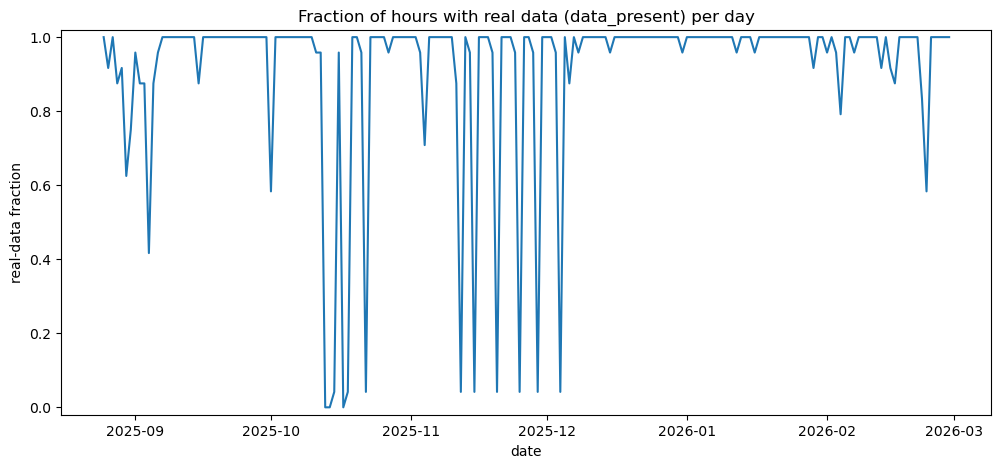

In [4]:
df_station = pd.read_csv(STATION_CSV_PATH)
df_station.columns = [c.strip() for c in df_station.columns]
df_station = ensure_hour_utc(df_station)

df_station = df_station.sort_values("hour_utc").reset_index(drop=True)

print("Station CSV shape:", df_station.shape)
display(df_station.head(3))

expected_cols = [
    "station_id", "timestamp_utc", "hour_utc", "latitude", "longitude",
    "temp_avg_c", "windspeed_avg_kmh", "winddir_avg_deg",
    "humidity_avg_pct", "dewpoint_avg_c",
    "pressure_avg_hpa", "pressure_max_hpa",
    "windgust_avg_kmh", "windgust_high_kmh",
    "precip_rate_mmh", "precip_total_mm",
    "uv_high", "solar_radiation_high_wm2",
    "data_present"
]
missing_expected = [c for c in expected_cols if c not in df_station.columns]
print("Missing expected columns (not fatal):", missing_expected)

dup_hours = df_station["hour_utc"].duplicated().sum()
print("Duplicate hour_utc rows:", dup_hours)

if "data_present" in df_station.columns:
    daily_present = df_station.set_index("hour_utc")["data_present"].resample("D").mean()
    plt.figure()
    plt.plot(daily_present.index, daily_present.values)
    plt.title("Fraction of hours with real data (data_present) per day")
    plt.ylim(-0.02, 1.02)
    plt.ylabel("real-data fraction")
    plt.xlabel("date")
    plt.show()

<h2>1.5: “timestamp within hour” diagnostic </h2>

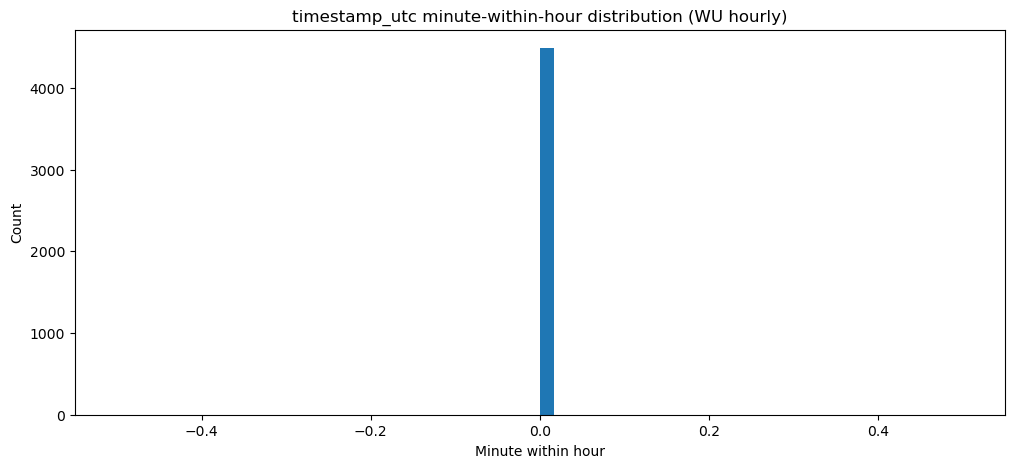

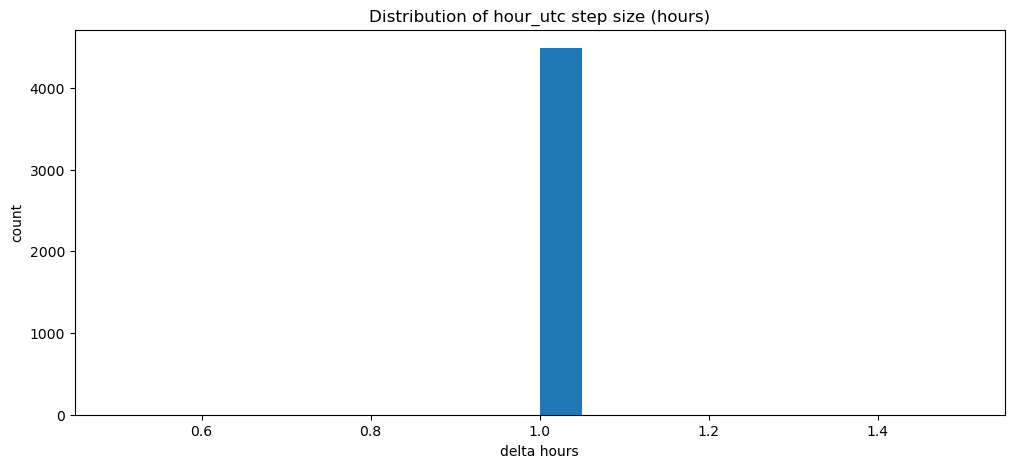

Most common deltas (hours):
hour_utc
1.0    4486
Name: count, dtype: int64


In [5]:
if "timestamp_utc" in df_station.columns:
    ts = to_utc_datetime(df_station["timestamp_utc"])
    mins = ts.dt.minute + ts.dt.second / 60.0

    plt.figure()
    plt.hist(mins.dropna(), bins=60)
    plt.title("timestamp_utc minute-within-hour distribution (WU hourly)")
    plt.xlabel("Minute within hour")
    plt.ylabel("Count")
    plt.show()

deltas = df_station["hour_utc"].diff().dt.total_seconds() / 3600.0
plt.figure()
plt.hist(deltas.dropna(), bins=20)
plt.title("Distribution of hour_utc step size (hours)")
plt.xlabel("delta hours")
plt.ylabel("count")
plt.show()

print("Most common deltas (hours):")
print(deltas.value_counts(dropna=True).head(10))

<h2>1.6: Apply broad QC range flags</h2>

QC range-flag columns: 10
Any out-of-range hours: 0


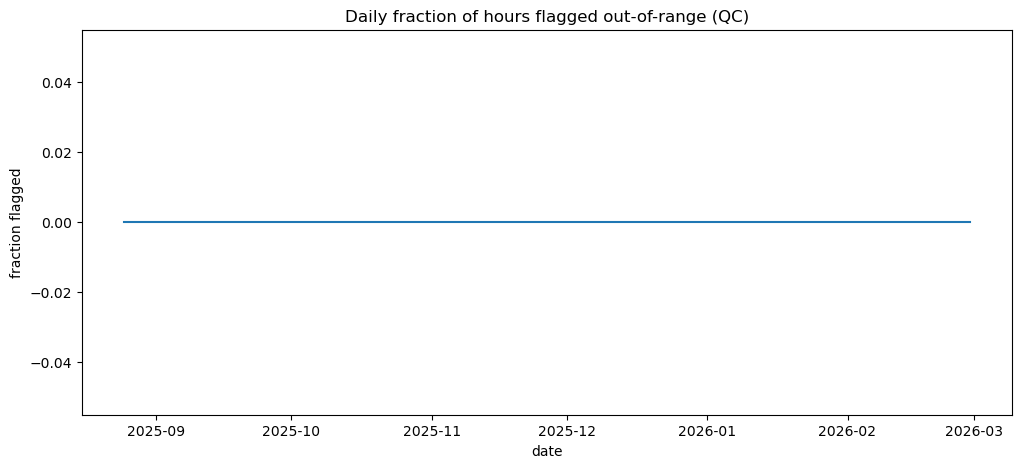

,hour_utc,n_raw_records,station_id,latitude,longitude,neighborhood,country,software_type,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_avg_hpa,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm


In [6]:
df_station_qc = apply_range_qc(df_station, QC_RANGES)

qc_cols = [c for c in df_station_qc.columns if c.startswith("qc_oor__")]
print("QC range-flag columns:", len(qc_cols))
print("Any out-of-range hours:", int(df_station_qc["qc_any_out_of_range"].sum()))

qc_daily = df_station_qc.set_index("hour_utc")["qc_any_out_of_range"].resample("D").mean()

plt.figure()
plt.plot(qc_daily.index, qc_daily.values)
plt.title("Daily fraction of hours flagged out-of-range (QC)")
plt.ylabel("fraction flagged")
plt.xlabel("date")
plt.show()

display(df_station_qc[df_station_qc["qc_any_out_of_range"] == 1].head(10))

<h2>1.7: Precipitation inference:</h2>

{
  "rate_mm_equiv": {
    "name": "rate_mm_equiv",
    "nonzero_frac": 0.00022286605749944285,
    "p50": 0.0,
    "p90": 0.0,
    "p99": 0.0,
    "max": 0.25
  },
  "total_inc_mm": {
    "name": "total_inc_mm",
    "nonzero_frac": 0.0004457321149988857,
    "p50": 0.0,
    "p90": 0.0,
    "p99": 0.0,
    "max": 0.25
  },
  "corr_rate_vs_totalinc": 0.7070192192047577
}


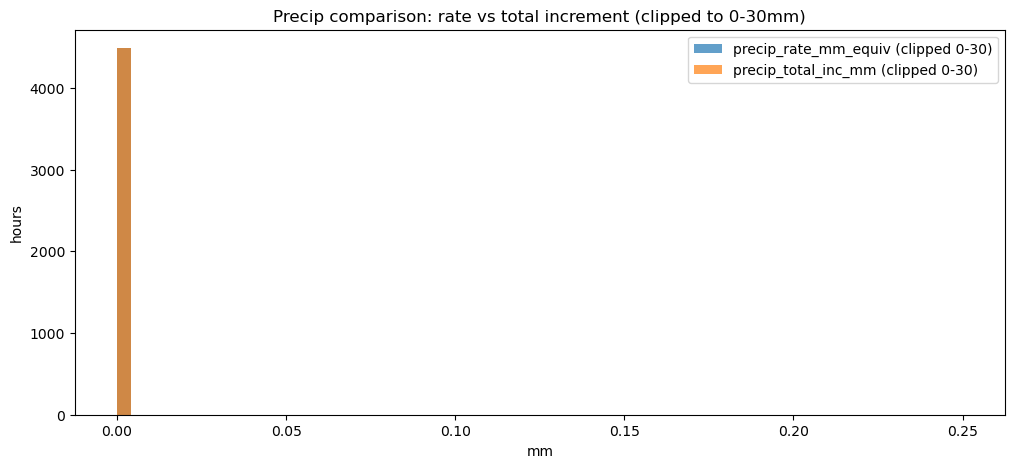

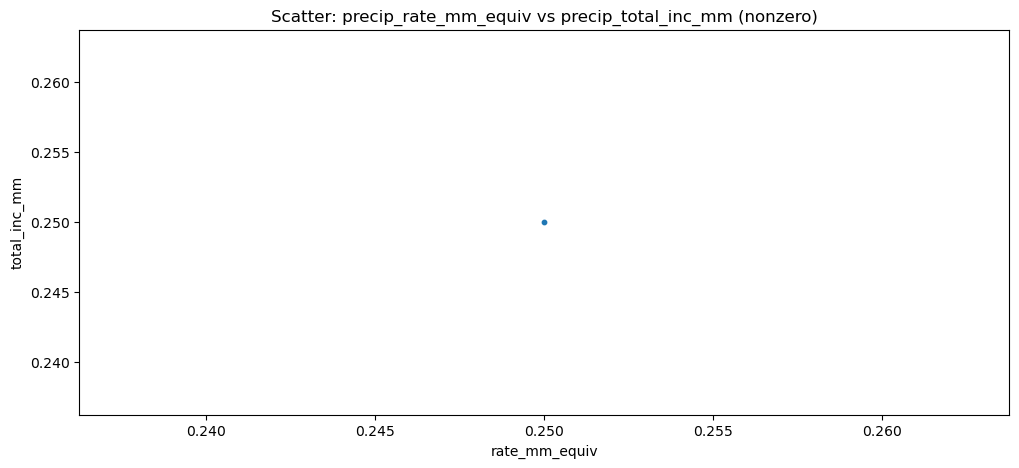

Chosen station_precip_mm source: precip_total_inc_mm


In [7]:
df = df_station_qc.copy().sort_values("hour_utc").reset_index(drop=True)

rate = pd.to_numeric(df.get("precip_rate_mmh"), errors="coerce")
tot = pd.to_numeric(df.get("precip_total_mm"), errors="coerce")

tot_diff = tot.diff()
tot_inc = np.where(tot_diff < 0, tot, tot_diff)  
tot_inc = pd.Series(tot_inc, index=df.index).clip(lower=0)

df["precip_total_inc_mm"] = tot_inc
df["precip_rate_mm_equiv"] = rate.clip(lower=0)  

def summarize_precip(name, s):
    s = pd.to_numeric(s, errors="coerce")
    return {
        "name": name,
        "nonzero_frac": float((s > 0).mean()),
        "p50": float(s.quantile(0.50)),
        "p90": float(s.quantile(0.90)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
    }

precip_summary = {
    "rate_mm_equiv": summarize_precip("rate_mm_equiv", df["precip_rate_mm_equiv"]),
    "total_inc_mm": summarize_precip("total_inc_mm", df["precip_total_inc_mm"]),
    "corr_rate_vs_totalinc": safe_corr(df["precip_rate_mm_equiv"], df["precip_total_inc_mm"]),
}

print(json.dumps(precip_summary, indent=2))

plt.figure()
plt.hist(df["precip_rate_mm_equiv"].fillna(0).clip(0, 30), bins=60, alpha=0.7, label="precip_rate_mm_equiv (clipped 0-30)")
plt.hist(df["precip_total_inc_mm"].fillna(0).clip(0, 30), bins=60, alpha=0.7, label="precip_total_inc_mm (clipped 0-30)")
plt.title("Precip comparison: rate vs total increment (clipped to 0-30mm)")
plt.xlabel("mm")
plt.ylabel("hours")
plt.legend()
plt.show()

mask = (df["precip_rate_mm_equiv"] > 0) & (df["precip_total_inc_mm"] > 0)
plt.figure()
plt.scatter(df.loc[mask, "precip_rate_mm_equiv"], df.loc[mask, "precip_total_inc_mm"], s=10)
plt.title("Scatter: precip_rate_mm_equiv vs precip_total_inc_mm (nonzero)")
plt.xlabel("rate_mm_equiv")
plt.ylabel("total_inc_mm")
plt.show()

corr = precip_summary["corr_rate_vs_totalinc"]
if not np.isnan(corr) and corr >= 0.6:
    df["station_precip_mm"] = df["precip_total_inc_mm"]
    precip_choice = "precip_total_inc_mm"
else:
    df["station_precip_mm"] = df["precip_rate_mm_equiv"]
    precip_choice = "precip_rate_mm_equiv"

print("Chosen station_precip_mm source:", precip_choice)
df["station_precip_choice"] = precip_choice

<h2>1.8: Open‑Meteo base forecast fetch</h2>

In [8]:
REQUEST_HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "pressure_msl",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
    "precipitation",
    "rain",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "sunshine_duration",
    "weather_code",
]

REQUEST_DAILY_VARS = ["sunrise", "sunset"]

BASE_RENAME = {
    "temperature_2m": "base_temp_c",
    "relative_humidity_2m": "base_humidity_pct",
    "dew_point_2m": "base_dewpoint_c",
    "pressure_msl": "base_pressure_msl_hpa",
    "surface_pressure": "base_surface_pressure_hpa",
    "wind_speed_10m": "base_windspeed_kmh",
    "wind_direction_10m": "base_winddir_deg",
    "wind_gusts_10m": "base_windgust_kmh",
    "precipitation": "base_precip_mm",
    "rain": "base_rain_mm",
    "cloud_cover": "base_cloud_pct",
    "cloud_cover_low": "base_cloud_low_pct",
    "cloud_cover_mid": "base_cloud_mid_pct",
    "cloud_cover_high": "base_cloud_high_pct",
    "shortwave_radiation": "base_shortwave_wm2",
    "direct_radiation": "base_direct_wm2",
    "diffuse_radiation": "base_diffuse_wm2",
    "sunshine_duration": "base_sunshine_sec",
    "weather_code": "base_weather_code",
}

def openmeteo_cache_key(lat, lon, start_date, end_date, model, hourly_vars, daily_vars):
    hv = ",".join(hourly_vars)
    dv = ",".join(daily_vars)
    return f"om_{lat:.5f}_{lon:.5f}_{start_date}_{end_date}_model{model}_H{hash(hv)}_D{hash(dv)}.json"

def fetch_openmeteo_json(lat, lon, start_date, end_date, model: Optional[str], hourly_vars, daily_vars, elevation_m=None):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_vars) if hourly_vars else None,
        "daily": ",".join(daily_vars) if daily_vars else None,
        "timezone": BASE_TIMEZONE,
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "precipitation_unit": "mm",
    }
    if model:
        params["models"] = model
    if elevation_m is not None:
        params["elevation"] = elevation_m

    params = {k: v for k, v in params.items() if v is not None}

    r = requests.get(BASE_API_HOST, params=params, timeout=45)
    data = r.json()
    if isinstance(data, dict) and data.get("error"):
        raise RuntimeError(data.get("reason", "Open-Meteo error"))
    r.raise_for_status()
    return data

def fetch_openmeteo_with_var_fallback(lat, lon, start_date, end_date, model_try_list, hourly_vars, daily_vars, elevation_m=None, max_passes=5):
    vars_current = list(hourly_vars)

    last_err = None
    for model in model_try_list + [None]:
        vars_current = list(hourly_vars)  
        for _ in range(max_passes):
            try:
                ck = openmeteo_cache_key(lat, lon, start_date, end_date, model or "auto", vars_current, daily_vars)
                cache_path = CACHE_DIR / ck
                if cache_path.exists():
                    data = json.loads(cache_path.read_text())
                else:
                    data = fetch_openmeteo_json(
                        lat, lon, start_date, end_date,
                        model=model,
                        hourly_vars=vars_current,
                        daily_vars=daily_vars,
                        elevation_m=elevation_m
                    )
                    cache_path.write_text(json.dumps(data))
                return data, model, vars_current
            except Exception as e:
                last_err = e
                msg = str(e)

                if "not supported" in msg.lower():
                    parts = msg.split(":")
                    if len(parts) >= 2:
                        bad = parts[-1]
                        bad_vars = [v.strip().strip(".") for v in bad.split(",")]
                        bad_vars = [v for v in bad_vars if v in vars_current]
                        if bad_vars:
                            print("Open-Meteo unsupported vars removed:", bad_vars)
                            vars_current = [v for v in vars_current if v not in bad_vars]
                            continue
                break

    raise RuntimeError(f"Open-Meteo fetch failed. Last error: {last_err}")

def openmeteo_to_frames(data: dict) -> Tuple[pd.DataFrame, pd.DataFrame]:
    hourly = data.get("hourly", {})
    if "time" not in hourly:
        raise RuntimeError("Open-Meteo response missing hourly.time")

    dfh = pd.DataFrame({"hour_utc": pd.to_datetime(hourly["time"], utc=True)})
    for k, arr in hourly.items():
        if k == "time":
            continue
        dfh[k] = arr

    for k, newk in BASE_RENAME.items():
        if k in dfh.columns:
            dfh = dfh.rename(columns={k: newk})

    dfd = pd.DataFrame()
    daily = data.get("daily", {})
    if daily and "time" in daily:
        dfd = pd.DataFrame({"date_utc": pd.to_datetime(daily["time"], utc=True).date})
        if "sunrise" in daily:
            dfd["sunrise_utc"] = pd.to_datetime(daily["sunrise"], utc=True)
        if "sunset" in daily:
            dfd["sunset_utc"] = pd.to_datetime(daily["sunset"], utc=True)
        if "sunrise_utc" in dfd.columns and "sunset_utc" in dfd.columns:
            dfd["daylight_duration_sec"] = (dfd["sunset_utc"] - dfd["sunrise_utc"]).dt.total_seconds()

    return dfh, dfd

<h2>1.9: Merge</h2>

In [9]:
lat = FORCE_LAT if FORCE_LAT is not None else float(df["latitude"].dropna().iloc[0])
lon = FORCE_LON if FORCE_LON is not None else float(df["longitude"].dropna().iloc[0])
elev = FORCE_ELEVATION_M

start_date = (df["hour_utc"].min() - pd.Timedelta(days=1)).date().isoformat()
end_date = (df["hour_utc"].max() + pd.Timedelta(days=1)).date().isoformat()

print("Fetching Open-Meteo baseline for:")
print(" lat/lon:", lat, lon, " elevation_m:", elev)
print(" start_date:", start_date, " end_date:", end_date)

data, used_model, used_hourly_vars = fetch_openmeteo_with_var_fallback(
    lat=lat, lon=lon,
    start_date=start_date, end_date=end_date,
    model_try_list=BASE_MODELS_TRY,
    hourly_vars=REQUEST_HOURLY_VARS,
    daily_vars=REQUEST_DAILY_VARS,
    elevation_m=elev
)

print("Open-Meteo model used:", used_model or "auto")
print("Hourly vars used:", used_hourly_vars)

df_base_h, df_base_d = openmeteo_to_frames(data)

print("Base hourly shape:", df_base_h.shape)
display(df_base_h.head(3))

dfm = df.merge(df_base_h, on="hour_utc", how="left")

if len(df_base_d) > 0:
    dfm["date_utc"] = dfm["hour_utc"].dt.date
    dfm = dfm.merge(df_base_d, on="date_utc", how="left")

dfm = drop_all_missing_columns(dfm)

print("Merged station+base shape:", dfm.shape)
display(dfm.head(3))

Fetching Open-Meteo baseline for:
 lat/lon: 29.124472 21.285446  elevation_m: 16
 start_date: 2025-08-24  end_date: 2026-03-01
Open-Meteo model used: ecmwf_ifs025
Hourly vars used: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'pressure_msl', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'precipitation', 'rain', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'weather_code']
Base hourly shape: (4560, 20)


,hour_utc,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code
0,2025-08-24 00:00:00+00:00,30.1,36,13.4,1010.4,1008.6,17.5,328,21.2,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0
1,2025-08-24 01:00:00+00:00,29.2,38,13.4,1010.4,1008.6,16.9,340,22.3,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0
2,2025-08-24 02:00:00+00:00,28.3,38,12.7,1010.6,1008.8,17.3,359,23.8,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0


Dropping 100% missing columns: ['neighborhood', 'country', 'software_type', 'pressure_avg_hpa']
Merged station+base shape: (4487, 78)


,hour_utc,n_raw_records,station_id,latitude,longitude,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm,precip_total_inc_mm,precip_rate_mm_equiv,station_precip_mm,station_precip_choice,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code,date_utc,sunrise_utc,sunset_utc,daylight_duration_sec
0,2025-08-25 22:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,-1.0,1.756159e+09,0.00,0.0,314.0,61.0,61.0,61.0,28.0,28.0,28.0,18.0,24.0,10.0,22.0,27.0,12.0,20.0,20.0,20.0,28.0,28.0,28.0,29.0,29.0,29.0,1005.08,1004.74,0.00,0.0,0.0,2025-08-25 22:00:00+00:00,2025-08-25T22:00:00Z,2025-08-25 23:59:37,1.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,precip_total_inc_mm,28.0,58,19.0,1014.3,1012.5,22.2,324,33.5,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-08-25,2025-08-25 04:09:00+00:00,2025-08-25 17:04:00+00:00,46500.0
1,2025-08-25 23:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,-1.0,1.756163e+09,0.00,0.0,316.0,59.0,61.0,56.0,28.0,28.0,27.0,18.0,28.0,11.0,22.0,31.0,13.0,19.0,20.0,18.0,28.0,28.0,27.0,29.0,29.0,28.0,1005.08,1004.06,-0.69,0.0,0.0,2025-08-25 23:00:00+00:00,2025-08-25T23:00:00Z,2025-08-26 00:59:38,1.0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,27.3,61,19.1,1013.9,1012.1,21.5,322,32.4,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-08-25,2025-08-25 04:09:00+00:00,2025-08-25 17:04:00+00:00,46500.0
2,2025-08-26 00:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,-1.0,1.756166e+09,6.09,13.0,311.0,52.0,56.0,51.0,27.0,28.0,27.0,18.0,28.0,12.0,22.0,35.0,15.0,17.0,18.0,16.0,27.0,28.0,27.0,28.0,28.0,27.0,1004.06,1003.73,0.00,0.0,0.0,2025-08-26 00:00:00+00:00,2025-08-26T00:00:00Z,2025-08-26 01:59:38,1.0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,26.7,63,19.1,1013.6,1011.8,20.5,322,31.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-08-26,2025-08-26 04:09:00+00:00,2025-08-26 17:03:00+00:00,46440.0


<h2>1.10: Build Targets and wind/solar </h2>

In [10]:
dfm = dfm.sort_values("hour_utc").reset_index(drop=True)

dfm["station_temp_c"] = pd.to_numeric(dfm.get("temp_avg_c"), errors="coerce")
dfm["station_rh_pct"] = pd.to_numeric(dfm.get("humidity_avg_pct"), errors="coerce")
dfm["station_dewpoint_c"] = pd.to_numeric(dfm.get("dewpoint_avg_c"), errors="coerce")
dfm["station_windspeed_kmh"] = pd.to_numeric(dfm.get("windspeed_avg_kmh"), errors="coerce")
dfm["station_winddir_deg"] = pd.to_numeric(dfm.get("winddir_avg_deg"), errors="coerce")

pressure_avg = pd.to_numeric(
    dfm.get("pressure_avg_hpa", pd.Series(index=dfm.index, dtype="float64")),
    errors="coerce"
)
pressure_max = pd.to_numeric(
    dfm.get("pressure_max_hpa", pd.Series(index=dfm.index, dtype="float64")),
    errors="coerce"
)
dfm["station_pressure_hpa"] = pressure_avg.where(pressure_avg.notna(), pressure_max)

dfm["station_gust_avg_kmh"] = pd.to_numeric(dfm.get("windgust_avg_kmh"), errors="coerce")
dfm["station_gust_high_kmh"] = pd.to_numeric(dfm.get("windgust_high_kmh"), errors="coerce")

dfm["station_precip_mm"] = pd.to_numeric(dfm.get("station_precip_mm"), errors="coerce")

dfm["uv_target"] = pd.to_numeric(dfm.get("uv_high"), errors="coerce")

dfm["temp_error_c"] = dfm["station_temp_c"] - pd.to_numeric(dfm.get("base_temp_c"), errors="coerce")
dfm["rh_error_pct"] = dfm["station_rh_pct"] - pd.to_numeric(dfm.get("base_humidity_pct"), errors="coerce")
dfm["dewpoint_error_c"] = dfm["station_dewpoint_c"] - pd.to_numeric(dfm.get("base_dewpoint_c"), errors="coerce")
dfm["wind_error_kmh"] = dfm["station_windspeed_kmh"] - pd.to_numeric(dfm.get("base_windspeed_kmh"), errors="coerce")
dfm["winddir_error_deg"] = circular_diff_deg(dfm["station_winddir_deg"], dfm.get("base_winddir_deg"))

base_rain = "base_rain_mm" if "base_rain_mm" in dfm.columns else ("base_precip_mm" if "base_precip_mm" in dfm.columns else None)
if base_rain:
    dfm["rain_error_mm"] = dfm["station_precip_mm"] - pd.to_numeric(dfm[base_rain], errors="coerce")
else:
    dfm["rain_error_mm"] = np.nan

dfm["pressure_error_vs_surface_hpa"] = dfm["station_pressure_hpa"] - pd.to_numeric(dfm.get("base_surface_pressure_hpa"), errors="coerce")
dfm["pressure_error_vs_msl_hpa"] = dfm["station_pressure_hpa"] - pd.to_numeric(dfm.get("base_pressure_msl_hpa"), errors="coerce")

dfm["station_gust_high_3hmax_kmh"] = dfm["station_gust_high_kmh"].rolling(3, min_periods=1).max()
dfm["gust_error_high_hourly_kmh"] = dfm["station_gust_high_kmh"] - pd.to_numeric(dfm.get("base_windgust_kmh"), errors="coerce")
dfm["gust_error_high_3hmax_kmh"] = dfm["station_gust_high_3hmax_kmh"] - pd.to_numeric(dfm.get("base_windgust_kmh"), errors="coerce")
dfm["gust_error_avg_hourly_kmh"] = dfm["station_gust_avg_kmh"] - pd.to_numeric(dfm.get("base_windgust_kmh"), errors="coerce")

dfm["station_u_kmh"], dfm["station_v_kmh"] = wind_to_uv(dfm["station_windspeed_kmh"], dfm["station_winddir_deg"])
dfm["base_u_kmh"], dfm["base_v_kmh"] = wind_to_uv(pd.to_numeric(dfm.get("base_windspeed_kmh"), errors="coerce"),
                                                  pd.to_numeric(dfm.get("base_winddir_deg"), errors="coerce"))
dfm["wind_u_error_kmh"] = dfm["station_u_kmh"] - dfm["base_u_kmh"]
dfm["wind_v_error_kmh"] = dfm["station_v_kmh"] - dfm["base_v_kmh"]

if "sunrise_utc" in dfm.columns and "sunset_utc" in dfm.columns:
    sunrise = pd.to_datetime(dfm["sunrise_utc"], utc=True, errors="coerce")
    sunset  = pd.to_datetime(dfm["sunset_utc"], utc=True, errors="coerce")
    dfm["is_day"] = ((dfm["hour_utc"] >= sunrise) & (dfm["hour_utc"] < sunset)).astype(float)
else:
    dfm["is_day"] = np.nan

display(dfm[[
    "hour_utc",
    "station_temp_c","base_temp_c","temp_error_c",
    "station_windspeed_kmh","base_windspeed_kmh","wind_error_kmh",
    "station_winddir_deg","base_winddir_deg","winddir_error_deg",
    "station_pressure_hpa","base_surface_pressure_hpa","base_pressure_msl_hpa",
    "pressure_error_vs_surface_hpa","pressure_error_vs_msl_hpa",
    "station_precip_mm", base_rain if base_rain else "station_precip_mm", "rain_error_mm",
    "uv_target"
]].head(8))

,hour_utc,station_temp_c,base_temp_c,temp_error_c,station_windspeed_kmh,base_windspeed_kmh,wind_error_kmh,station_winddir_deg,base_winddir_deg,winddir_error_deg,station_pressure_hpa,base_surface_pressure_hpa,base_pressure_msl_hpa,pressure_error_vs_surface_hpa,pressure_error_vs_msl_hpa,station_precip_mm,base_rain_mm,rain_error_mm,uv_target
0,2025-08-25 22:00:00+00:00,28.0,28.0,0.0,18.0,22.2,-4.2,314.0,324,-10.0,1005.08,1012.5,1014.3,-7.42,-9.22,NaN,0.0,NaN,0.0
1,2025-08-25 23:00:00+00:00,28.0,27.3,0.7,18.0,21.5,-3.5,316.0,322,-6.0,1005.08,1012.1,1013.9,-7.02,-8.82,0.0,0.0,0.0,0.0
2,2025-08-26 00:00:00+00:00,27.0,26.7,0.3,18.0,20.5,-2.5,311.0,322,-11.0,1004.06,1011.8,1013.6,-7.74,-9.54,0.0,0.0,0.0,13.0
3,2025-08-26 01:00:00+00:00,27.0,26.1,0.9,15.0,19.6,-4.6,37.0,328,69.0,1004.06,1011.6,1013.4,-7.54,-9.34,0.0,0.0,0.0,0.0
4,2025-08-26 02:00:00+00:00,26.0,25.6,0.4,12.0,18.9,-6.9,193.0,336,-143.0,1004.06,1011.5,1013.4,-7.44,-9.34,0.0,0.0,0.0,0.0
5,2025-08-26 03:00:00+00:00,26.0,25.4,0.6,8.0,17.8,-9.8,36.0,346,50.0,1004.06,1011.5,1013.4,-7.44,-9.34,0.0,0.0,0.0,1.0
6,2025-08-26 04:00:00+00:00,24.0,25.4,-1.4,5.0,15.9,-10.9,5.0,355,10.0,1004.40,1011.7,1013.6,-7.30,-9.20,0.0,0.0,0.0,0.0
7,2025-08-26 05:00:00+00:00,24.0,25.7,-1.7,6.0,14.1,-8.1,114.0,6,108.0,1005.08,1012.1,1014.0,-7.02,-8.92,0.0,0.0,0.0,1.0


<h2>1.11: diagnose time alignment </h2>

Lag diagnosis (temp): {'station_col': 'station_temp_c', 'base_col': 'base_temp_c', 'corr_by_lag': {-3: 0.8722967836369114, -2: 0.9316678265258325, -1: 0.9715617155789504, 0: 0.9856052704656931, 1: 0.9697526605300751, 2: 0.9279930924477127, 3: 0.8660480077454976}, 'best_lag': 0, 'best_corr': 0.9856052704656931}
Lag diagnosis (wind): {'station_col': 'station_windspeed_kmh', 'base_col': 'base_windspeed_kmh', 'corr_by_lag': {-3: 0.6146400852927918, -2: 0.6870772127197625, -1: 0.7381808596422674, 0: 0.7531582269795422, 1: 0.7252852896510307, 2: 0.6705765451281777, 3: 0.6027206537778584}, 'best_lag': 0, 'best_corr': 0.7531582269795422}


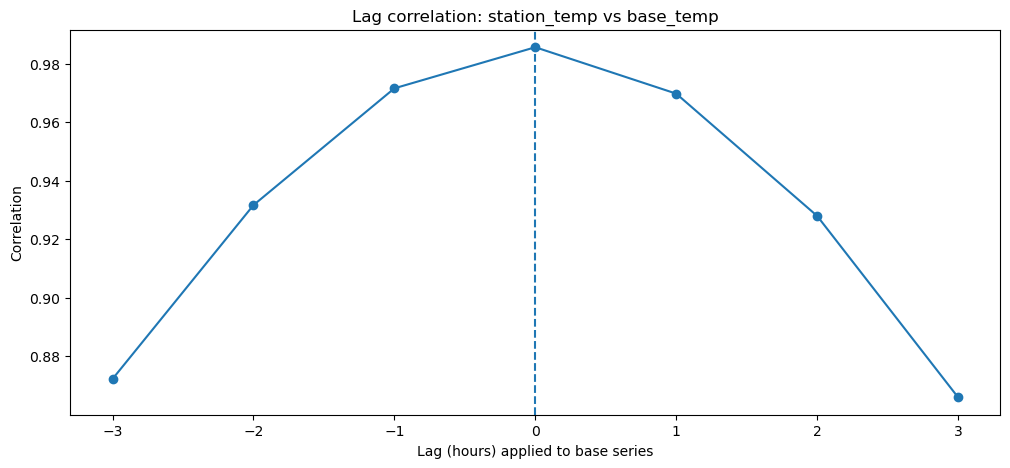

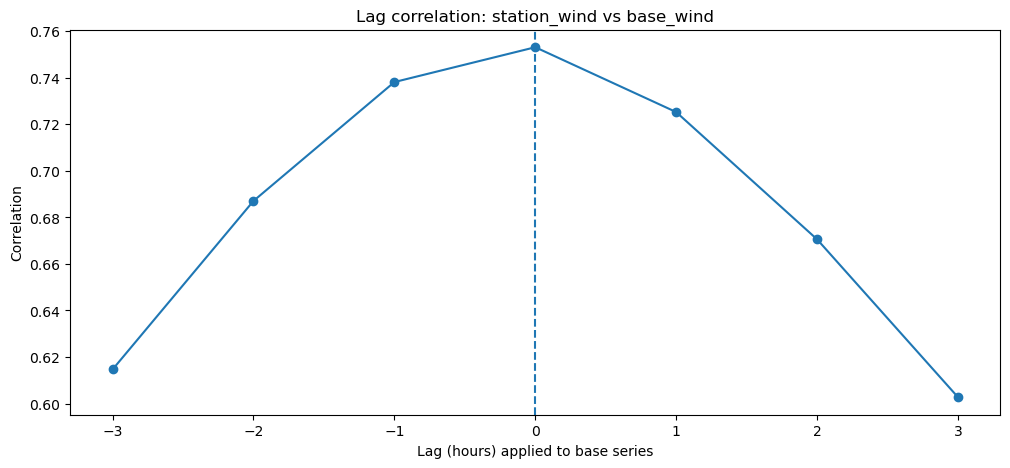

In [11]:
diagnostics = {}

df_real = dfm.copy()
if "data_present" in df_real.columns:
    df_real = df_real[df_real["data_present"] == 1].copy()

lag_temp = compute_best_lag_correlation(df_real, "station_temp_c", "base_temp_c", LAG_TEST_RANGE)
lag_wind = compute_best_lag_correlation(df_real, "station_windspeed_kmh", "base_windspeed_kmh", LAG_TEST_RANGE)

diagnostics["lag_temp"] = lag_temp
diagnostics["lag_wind"] = lag_wind

print("Lag diagnosis (temp):", lag_temp)
print("Lag diagnosis (wind):", lag_wind)

def plot_lag(res, title):
    lags = sorted(res["corr_by_lag"].keys())
    vals = [res["corr_by_lag"][l] for l in lags]
    plt.figure()
    plt.plot(lags, vals, marker="o")
    plt.title(title)
    plt.xlabel("Lag (hours) applied to base series")
    plt.ylabel("Correlation")
    plt.axvline(0, linestyle="--")
    plt.show()

plot_lag(lag_temp, "Lag correlation: station_temp vs base_temp")
plot_lag(lag_wind, "Lag correlation: station_wind vs base_wind")

note: seems to have gone back to zero here

<h2>1.12: diagnose pressure type </h2>

{
  "n": 4088,
  "mae_vs_surface": 7.367827788649711,
  "mae_vs_msl": 9.213008806262232,
  "corr_vs_surface": 0.9231396983039079,
  "corr_vs_msl": 0.9233514619463725,
  "mean_station_minus_surface": -7.249995107632099,
  "mean_station_minus_msl": -9.143904109589045,
  "likely_station_pressure_type": "station_surface (closer to base surface)"
}


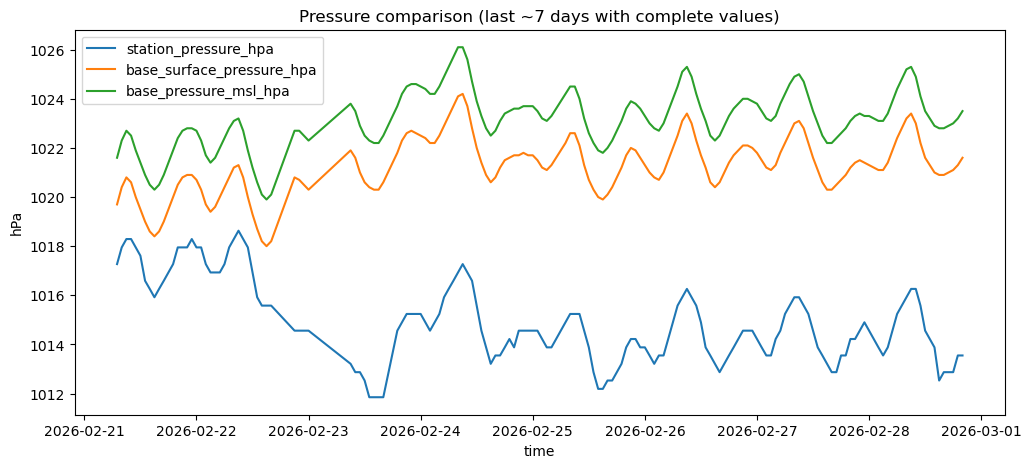

In [12]:
s = pd.to_numeric(df_real["station_pressure_hpa"], errors="coerce")
surf = pd.to_numeric(df_real.get("base_surface_pressure_hpa"), errors="coerce")
msl  = pd.to_numeric(df_real.get("base_pressure_msl_hpa"), errors="coerce")

pressure_diag = {
    "n": int(s.notna().sum()),
    "mae_vs_surface": float((s - surf).abs().mean()) if surf is not None else None,
    "mae_vs_msl": float((s - msl).abs().mean()) if msl is not None else None,
    "corr_vs_surface": safe_corr(s, surf),
    "corr_vs_msl": safe_corr(s, msl),
    "mean_station_minus_surface": float((s - surf).mean()) if surf is not None else None,
    "mean_station_minus_msl": float((s - msl).mean()) if msl is not None else None,
}

if pressure_diag["mae_vs_surface"] is not None and pressure_diag["mae_vs_msl"] is not None:
    if pressure_diag["mae_vs_msl"] + 0.5 < pressure_diag["mae_vs_surface"]:
        pressure_diag["likely_station_pressure_type"] = "sea_level_relative (closer to base MSL)"
        pressure_choice = "msl"
    elif pressure_diag["mae_vs_surface"] + 0.5 < pressure_diag["mae_vs_msl"]:
        pressure_diag["likely_station_pressure_type"] = "station_surface (closer to base surface)"
        pressure_choice = "surface"
    else:
        pressure_diag["likely_station_pressure_type"] = "ambiguous_or_mixed"
        pressure_choice = "ambiguous"
else:
    pressure_choice = "unknown"

diagnostics["pressure_diagnosis"] = pressure_diag
diagnostics["pressure_choice"] = pressure_choice

print(json.dumps(pressure_diag, indent=2))

sample = df_real[["hour_utc","station_pressure_hpa","base_surface_pressure_hpa","base_pressure_msl_hpa"]].dropna().tail(7*24)

plt.figure()
plt.plot(sample["hour_utc"], sample["station_pressure_hpa"], label="station_pressure_hpa")
if "base_surface_pressure_hpa" in sample.columns:
    plt.plot(sample["hour_utc"], sample["base_surface_pressure_hpa"], label="base_surface_pressure_hpa")
if "base_pressure_msl_hpa" in sample.columns:
    plt.plot(sample["hour_utc"], sample["base_pressure_msl_hpa"], label="base_pressure_msl_hpa")
plt.title("Pressure comparison (last ~7 days with complete values)")
plt.xlabel("time")
plt.ylabel("hPa")
plt.legend()
plt.show()

note: pressure here seems to have started out well then shifted for some reason to a very low value jusr like the tripoli case

<h2>1.13: diagnose gust </h2>

Gust diagnosis (sorted by MAE):
[
  {
    "name": "station_gust_high_3hmax_kmh",
    "n": 4088,
    "mae": 5.73094422700587,
    "bias": -3.4905332681017613,
    "corr": 0.8393131260396152
  },
  {
    "name": "station_gust_high_kmh",
    "n": 4088,
    "mae": 7.262035225048923,
    "bias": -6.417514677103718,
    "corr": 0.8449491346225403
  },
  {
    "name": "station_gust_avg_kmh",
    "n": 4088,
    "mae": 13.164750489236791,
    "bias": -13.136325831702544,
    "corr": 0.8502379182669734
  }
]
Chosen gust alignment: station_gust_high_3hmax_kmh


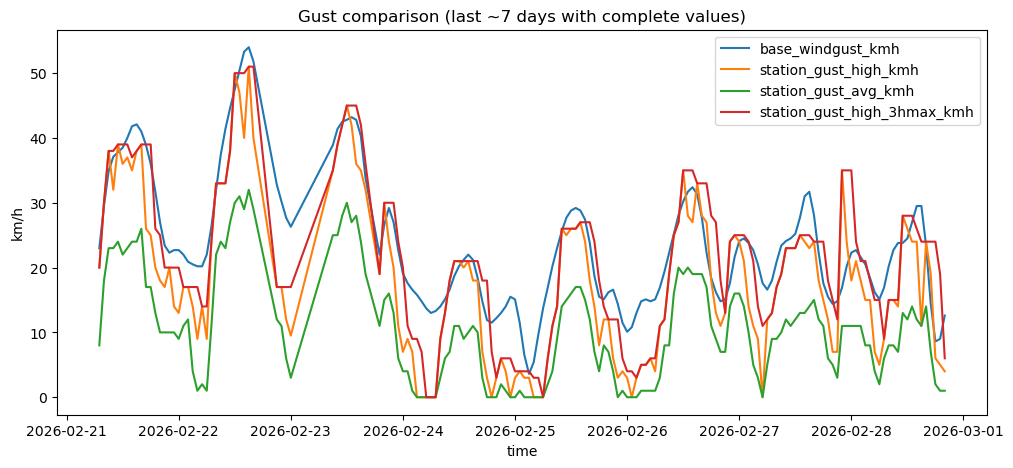

In [13]:
base_gust = pd.to_numeric(df_real.get("base_windgust_kmh"), errors="coerce")

def gust_stats(name, s):
    s = pd.to_numeric(s, errors="coerce")
    mask = s.notna() & base_gust.notna()
    if mask.sum() < 100:
        return {"name": name, "n": int(mask.sum()), "mae": None, "bias": None, "corr": None}
    return {
        "name": name,
        "n": int(mask.sum()),
        "mae": float((s[mask] - base_gust[mask]).abs().mean()),
        "bias": float((s[mask] - base_gust[mask]).mean()),
        "corr": float(s[mask].corr(base_gust[mask])),
    }

gust_diag = [
    gust_stats("station_gust_avg_kmh", df_real.get("station_gust_avg_kmh")),
    gust_stats("station_gust_high_kmh", df_real.get("station_gust_high_kmh")),
    gust_stats("station_gust_high_3hmax_kmh", df_real.get("station_gust_high_3hmax_kmh")),
]

gust_diag_sorted = sorted([g for g in gust_diag if g["mae"] is not None], key=lambda x: x["mae"])
diagnostics["gust_diagnosis"] = gust_diag_sorted

if gust_diag_sorted:
    best = gust_diag_sorted[0]["name"]
else:
    best = "unknown"

diagnostics["gust_choice"] = best

print("Gust diagnosis (sorted by MAE):")
print(json.dumps(gust_diag_sorted, indent=2))
print("Chosen gust alignment:", best)

sample = df_real[["hour_utc","base_windgust_kmh","station_gust_avg_kmh","station_gust_high_kmh","station_gust_high_3hmax_kmh"]].dropna().tail(7*24)

plt.figure()
plt.plot(sample["hour_utc"], sample["base_windgust_kmh"], label="base_windgust_kmh")
plt.plot(sample["hour_utc"], sample["station_gust_high_kmh"], label="station_gust_high_kmh")
plt.plot(sample["hour_utc"], sample["station_gust_avg_kmh"], label="station_gust_avg_kmh")
plt.plot(sample["hour_utc"], sample["station_gust_high_3hmax_kmh"], label="station_gust_high_3hmax_kmh")
plt.title("Gust comparison (last ~7 days with complete values)")
plt.xlabel("time")
plt.ylabel("km/h")
plt.legend()
plt.show()

note: didn't give the same result as tripoli

<h2>1.14: first bad days mask test</h2>

First real hour: 2025-08-25 22:00:00+00:00
Cutoff (remove first N days): 2025-08-25 22:00:00+00:00
Before: (4487, 106) After: (4487, 106)


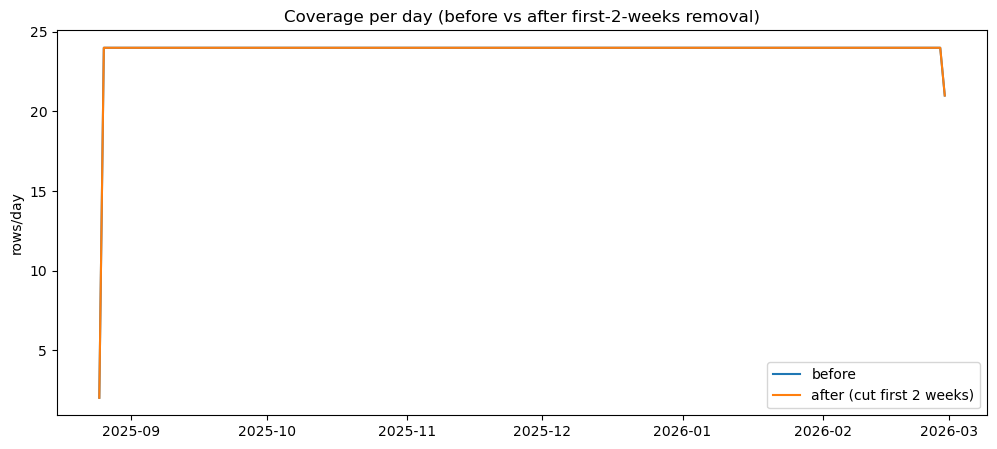

,mean_before,mean_after,std_before,std_after
winddir_error_deg,-12.104941,-12.104941,55.628563,55.628563
pressure_error_vs_msl_hpa,-9.143904,-9.143904,1.750726,1.750726
pressure_error_vs_surface_hpa,-7.249995,-7.249995,1.752773,1.752773
wind_error_kmh,-7.024315,-7.024315,4.368079,4.368079
gust_error_high_hourly_kmh,-6.417515,-6.417515,5.837344,5.837344
gust_error_high_3hmax_kmh,-3.505059,-3.505059,6.201997,6.201997
temp_error_c,-0.069618,-0.069618,1.238843,1.238843
rain_error_mm,-0.000322,-0.000322,0.009502,0.009502
dewpoint_error_c,0.528914,0.528914,1.992630,1.992630
rh_error_pct,0.676248,0.676248,6.089210,6.089210


In [14]:
df_clean = dfm.copy().sort_values("hour_utc").reset_index(drop=True)

if "data_present" in df_clean.columns:
    first_real = df_clean.loc[df_clean["data_present"] == 1, "hour_utc"].min()
    if pd.isna(first_real):
        first_real = df_clean["hour_utc"].min()
else:
    first_real = df_clean["hour_utc"].min()

cutoff = first_real + pd.Timedelta(days=REMOVE_FIRST_N_DAYS)
print("First real hour:", first_real)
print("Cutoff (remove first N days):", cutoff)

before_shape = df_clean.shape
df_clean = df_clean[df_clean["hour_utc"] >= cutoff].copy().reset_index(drop=True)
after_shape = df_clean.shape
print("Before:", before_shape, "After:", after_shape)

before_counts = dfm.set_index("hour_utc").resample("D").size()
after_counts  = df_clean.set_index("hour_utc").resample("D").size()

plt.figure()
plt.plot(before_counts.index, before_counts.values, label="before")
plt.plot(after_counts.index, after_counts.values, label="after (cut first 2 weeks)")
plt.title("Coverage per day (before vs after first-2-weeks removal)")
plt.ylabel("rows/day")
plt.legend()
plt.show()

targets = ["temp_error_c","wind_error_kmh","rh_error_pct","dewpoint_error_c","pressure_error_vs_surface_hpa","pressure_error_vs_msl_hpa","rain_error_mm","gust_error_high_hourly_kmh","gust_error_high_3hmax_kmh","winddir_error_deg"]
summary = pd.DataFrame({
    "mean_before": [pd.to_numeric(dfm.get(t), errors="coerce").mean() for t in targets],
    "mean_after":  [pd.to_numeric(df_clean.get(t), errors="coerce").mean() for t in targets],
    "std_before":  [pd.to_numeric(dfm.get(t), errors="coerce").std() for t in targets],
    "std_after":   [pd.to_numeric(df_clean.get(t), errors="coerce").std() for t in targets],
}, index=targets)

display(summary.sort_values("mean_after"))

note: i checked the table and actually removed 18 days becasue the values were 0 up until day 18

<h2>1.15: export </h2>

In [15]:
df_clean = drop_all_missing_columns(df_clean)

out_csv = OUTPUT_DIR / f"train_table_v2_{STATION_ID}.csv"
df_clean.to_csv(out_csv, index=False)
print("Saved:", out_csv)

diagnostics["station_id"] = STATION_ID
diagnostics["lat"] = float(lat)
diagnostics["lon"] = float(lon)
diagnostics["elevation_m_used"] = float(elev) if elev is not None else None
diagnostics["openmeteo_model_used"] = used_model or "auto"
diagnostics["openmeteo_hourly_vars_used"] = used_hourly_vars
diagnostics["precip_choice"] = precip_choice

diag_path = OUTPUT_DIR / f"diagnostics_v2_{STATION_ID}.json"
diag_path.write_text(json.dumps(diagnostics, indent=2))
print("Saved diagnostics:", diag_path)

display(df_clean.head(3))
print("Final columns:", len(df_clean.columns))

Saved: eda_v2_outputs_part1\train_table_v2_IALWAH18.csv
Saved diagnostics: eda_v2_outputs_part1\diagnostics_v2_IALWAH18.json


,hour_utc,n_raw_records,station_id,latitude,longitude,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm,precip_total_inc_mm,precip_rate_mm_equiv,station_precip_mm,station_precip_choice,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code,date_utc,sunrise_utc,sunset_utc,daylight_duration_sec,station_temp_c,station_rh_pct,station_dewpoint_c,station_windspeed_kmh,station_winddir_deg,station_pressure_hpa,station_gust_avg_kmh,station_gust_high_kmh,uv_target,temp_error_c,rh_error_pct,dewpoint_error_c,wind_error_kmh,winddir_error_deg,rain_error_mm,pressure_error_vs_surface_hpa,pressure_error_vs_msl_hpa,station_gust_high_3hmax_kmh,gust_error_high_hourly_kmh,gust_error_high_3hmax_kmh,gust_error_avg_hourly_kmh,station_u_kmh,station_v_kmh,base_u_kmh,base_v_kmh,wind_u_error_kmh,wind_v_error_kmh,is_day
0,2025-08-25 22:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,-1.0,1.756159e+09,0.00,0.0,314.0,61.0,61.0,61.0,28.0,28.0,28.0,18.0,24.0,10.0,22.0,27.0,12.0,20.0,20.0,20.0,28.0,28.0,28.0,29.0,29.0,29.0,1005.08,1004.74,0.00,0.0,0.0,2025-08-25 22:00:00+00:00,2025-08-25T22:00:00Z,2025-08-25 23:59:37,1.0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,precip_total_inc_mm,28.0,58,19.0,1014.3,1012.5,22.2,324,33.5,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-08-25,2025-08-25 04:09:00+00:00,2025-08-25 17:04:00+00:00,46500.0,28.0,61.0,20.0,18.0,314.0,1005.08,22.0,27.0,0.0,0.0,3.0,1.0,-4.2,-10.0,NaN,-7.42,-9.22,27.0,-6.5,-6.5,-11.5,12.948116,-12.503851,13.048833,-17.960177,-0.100716,5.456327,0.0
1,2025-08-25 23:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,-1.0,1.756163e+09,0.00,0.0,316.0,59.0,61.0,56.0,28.0,28.0,27.0,18.0,28.0,11.0,22.0,31.0,13.0,19.0,20.0,18.0,28.0,28.0,27.0,29.0,29.0,28.0,1005.08,1004.06,-0.69,0.0,0.0,2025-08-25 23:00:00+00:00,2025-08-25T23:00:00Z,2025-08-26 00:59:38,1.0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,27.3,61,19.1,1013.9,1012.1,21.5,322,32.4,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-08-25,2025-08-25 04:09:00+00:00,2025-08-25 17:04:00+00:00,46500.0,28.0,59.0,19.0,18.0,316.0,1005.08,22.0,31.0,0.0,0.7,-2.0,-0.1,-3.5,-6.0,0.0,-7.02,-8.82,31.0,-1.4,-1.4,-10.4,12.503851,-12.948116,13.236722,-16.942231,-0.732871,3.994115,0.0
2,2025-08-26 00:00:00+00:00,1.0,IALWAH18,29.124472,21.285446,-1.0,1.756166e+09,6.09,13.0,311.0,52.0,56.0,51.0,27.0,28.0,27.0,18.0,28.0,12.0,22.0,35.0,15.0,17.0,18.0,16.0,27.0,28.0,27.0,28.0,28.0,27.0,1004.06,1003.73,0.00,0.0,0.0,2025-08-26 00:00:00+00:00,2025-08-26T00:00:00Z,2025-08-26 01:59:38,1.0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,26.7,63,19.1,1013.6,1011.8,20.5,322,31.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-08-26,2025-08-26 04:09:00+00:00,2025-08-26 17:03:00+00:00,46440.0,27.0,52.0,17.0,18.0,311.0,1004.06,22.0,35.0,13.0,0.3,-11.0,-2.1,-2.5,-11.0,0.0,-7.74,-9.54,35.0,4.0,4.0,-9.0,13.584772,-11.809063,12.621060,-16.154220,0.963712,4.345158,0.0


Final columns: 106
